# Logistic Regression: Tuning & Feature Selection Experiments

Feature selection first, then hyperparameter tuning — each experiment builds on the prior decision, narrowing toward the best LR configuration.

**Experiment Plan:**
1. Remove Accident Type (dominant shortcut feature)
2. Track Type vs Signalization (correlated pair, r = −0.52)
3. RUCC_2023 vs RUCC_Metro_Adjacency (derived pair, r = 0.87)
4. Lock feature set
5. GridSearchCV on L-BFGS / L2
6. SAGA solver with L1 penalty (sparsity analysis)
7. GridSearchCV on SAGA / L1

All experiments use 5-fold stratified CV on the 80% training set; primary metric is weighted F1.

---

## Setup

In [43]:
import pandas as pd
import numpy as np
import json
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    classification_report, f1_score, confusion_matrix,
    precision_score, recall_score, make_scorer
)

import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
style.use('tableau-colorblind10')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

RANDOM_SEED = 521
np.random.seed(RANDOM_SEED)

CAUSE_ORDER = ['E', 'H', 'M', 'S', 'T']
CAUSE_LABELS = {
    'E': 'Environmental', 'H': 'Human Factor',
    'M': 'Mechanical', 'S': 'Signal', 'T': 'Track'
}

## Helper Functions

Reusable functions for building pipelines, running CV, saving results, and comparing experiments. Defined once here to avoid code duplication across experiments.

In [44]:
def build_lr_pipeline(categorical_features, numeric_features, **lr_kwargs):
    """
    Build a sklearn Pipeline: OneHotEncoder -> StandardScaler -> LogisticRegression.
    
    Parameters
    ----------
    categorical_features : list of str
        Columns to one-hot encode.
    numeric_features : list of str
        Columns to pass through directly.
    **lr_kwargs : dict
        Additional keyword arguments passed to LogisticRegression
        (e.g., solver, penalty, C, class_weight).
    
    Returns
    -------
    Pipeline
    """
    # Set defaults if not provided
    lr_params = {
        'solver': 'lbfgs',
        'max_iter': 1000,
        'random_state': RANDOM_SEED
    }
    lr_params.update(lr_kwargs)
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), 
             categorical_features),
            ('num', 'passthrough', numeric_features)
        ]
    )
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(**lr_params))
    ])
    
    return pipeline


def run_cv_experiment(pipeline, X, y, n_splits=5):
    """
    Run stratified k-fold CV and return per-fold scores, mean, and std.
    
    Parameters
    ----------
    pipeline : sklearn Pipeline
        The model pipeline to evaluate.
    X : DataFrame
        Feature matrix.
    y : Series
        Target variable.
    n_splits : int
        Number of CV folds.
    
    Returns
    -------
    dict with keys: 'scores', 'mean', 'std', 'per_class_metrics', 'last_fold_predictions'
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    
    scores = []
    last_y_val = None
    last_y_pred = None
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_tr = X.iloc[train_idx]
        X_val = X.iloc[val_idx]
        y_tr = y.iloc[train_idx]
        y_val = y.iloc[val_idx]
        
        pipeline.fit(X_tr, y_tr)
        y_pred = pipeline.predict(X_val)
        f1 = f1_score(y_val, y_pred, average='weighted')
        scores.append(f1)
        
        # Keep last fold for detailed metrics
        last_y_val = y_val
        last_y_pred = y_pred
    
    # Per-class metrics from last fold
    precision_per_class = precision_score(last_y_val, last_y_pred, average=None,
                                          labels=CAUSE_ORDER, zero_division=0)
    recall_per_class = recall_score(last_y_val, last_y_pred, average=None,
                                    labels=CAUSE_ORDER, zero_division=0)
    f1_per_class = f1_score(last_y_val, last_y_pred, average=None,
                            labels=CAUSE_ORDER, zero_division=0)
    
    per_class = pd.DataFrame({
        'Cause': CAUSE_ORDER,
        'Precision': precision_per_class.round(3),
        'Recall': recall_per_class.round(3),
        'F1': f1_per_class.round(3)
    })
    
    return {
        'scores': [float(s) for s in scores],
        'mean': float(np.mean(scores)),
        'std': float(np.std(scores)),
        'per_class_metrics': per_class,
        'last_y_val': last_y_val,
        'last_y_pred': last_y_pred
    }


def save_experiment(results, features, experiment_name, filepath, **extra_fields):
    """
    Save experiment results to JSON.
    
    Parameters
    ----------
    results : dict
        Output from run_cv_experiment().
    features : dict
        {'categorical': [...], 'numeric': [...]}
    experiment_name : str
        Human-readable experiment label.
    filepath : str
        Path to save JSON.
    **extra_fields : dict
        Any additional fields to include (e.g., lr_params, notes).
    """
    output = {
        'experiment': experiment_name,
        'model': 'Logistic Regression',
        'features': {
            'categorical': features['categorical'],
            'numeric': features['numeric'],
            'total': len(features['categorical']) + len(features['numeric'])
        },
        'cv_folds': 5,
        'cv_scores': results['scores'],
        'cv_mean': results['mean'],
        'cv_std': results['std'],
        'per_class_metrics': results['per_class_metrics'].to_dict('records'),
        'random_seed': RANDOM_SEED
    }
    output.update(extra_fields)
    
    with open(filepath, 'w') as f:
        json.dump(output, f, indent=4)
    
    print(f"Saved: {filepath}")


def compare_experiments(names, filepaths):
    print("=" * 65)
    print(f"{'Experiment':<35} {'CV Mean':>10} {'CV Std':>10} {'Features':>8}")
    print("-" * 65)
    
    for name, fp in zip(names, filepaths):
        with open(fp, 'r') as f:
            data = json.load(f)
        
        # Handle different JSON key formats
        mean = data.get('cv_mean', 0)
        std = data.get('cv_std', data.get('baseline_cv_std', 0))
        
        if isinstance(data.get('features'), dict):
            n_feat = data['features']['total']
        elif isinstance(data.get('features'), list):
            n_feat = len(data['features'])
        else:
            n_feat = '?'
        
        print(f"{name:<35} {mean:>10.4f} {std:>10.4f} {n_feat:>8}")
    
    print("=" * 65)


def plot_cv_comparison(experiments, title='CV Comparison'):
    """
    Plot per-fold F1 scores for multiple experiments.
    
    Parameters
    ----------
    experiments : list of tuples
        Each tuple: (label, scores_list, marker)
    title : str
        Plot title.
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    folds = np.arange(1, 6)
    
    markers = ['o', 's', '^', 'D', 'v']
    linestyles = ['-', '--', '-.', ':', '-']
    
    for i, (label, scores) in enumerate(experiments):
        mean = np.mean(scores)
        ax.plot(folds, scores, marker=markers[i % len(markers)], 
                linewidth=2, linestyle=linestyles[i % len(linestyles)],
                label=f'{label} (mean={mean:.4f})')
        ax.axhline(y=mean, linestyle=':', alpha=0.3)
    
    ax.set_xlabel('Fold')
    ax.set_ylabel('Weighted F1-Score')
    ax.set_title(title)
    ax.set_xticks(folds)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_per_class_comparison(results_list, labels, title='Per-Class F1 Comparison'):
    """
    Side-by-side per-class F1 bars for multiple experiments.
    
    Parameters
    ----------
    results_list : list of DataFrames
        Each DataFrame has columns: Cause, Precision, Recall, F1
    labels : list of str
        Experiment labels.
    title : str
        Plot title.
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    
    x = np.arange(len(CAUSE_ORDER))
    n = len(results_list)
    width = 0.8 / n
    hatches = ['//', '..', 'xx', '\\\\', '++']
    
    for i, (df, label) in enumerate(zip(results_list, labels)):
        offset = (i - n/2 + 0.5) * width
        bars = ax.bar(x + offset, df['F1'], width, label=label)
        for bar in bars:
            bar.set_hatch(hatches[i % len(hatches)])
    
    ax.set_xlabel('Cause Category')
    ax.set_ylabel('F1-Score')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{c}" for c in CAUSE_ORDER])
    ax.legend()
    ax.set_ylim(0, 1.0)
    plt.tight_layout()
    plt.show()

print("Helper functions defined.")

Helper functions defined.


## Load Training Data

In [45]:
df_train = pd.read_csv('../../data/splits/train_80.csv', low_memory=False)

target = 'Cause_Category'
y_train = df_train[target].copy()

print(f"Training set: {len(df_train)} rows")
print(f"\nCause_Category distribution:")
print(y_train.value_counts(normalize=True).round(3))

Training set: 27640 rows

Cause_Category distribution:
Cause_Category
H    0.393
M    0.256
T    0.218
E    0.108
S    0.025
Name: proportion, dtype: float64


In [46]:
# Load baseline results for comparison throughout experiments
with open('results/lr/lr_baseline_results.json', 'r') as f:
    baseline_results = json.load(f)

print(f"Baseline LR CV: {baseline_results['cv_mean']:.4f} +/- {baseline_results['cv_std']:.4f}")
print(f"Baseline features: {baseline_results['features']}")

Baseline LR CV: 0.5358 +/- 0.0046
Baseline features: {'categorical': ['Weather Condition', 'Track Type', 'Visibility', 'Accident Type', 'Region'], 'numeric': ['RUCC_2023'], 'total': 6}


---

# Section 1: Feature Selection Experiments

## Experiment 1: Remove Accident Type

Phase 3 ARM-CBA analysis flagged Accident Type as a label leakage problem:
- **ARM:** Zero rules generated when Accident Type excluded (even at support 0.005, confidence 0.50, lift 1.0)
- **Chi-Square:** Strongest association with Cause_Category among all features

Accident Type describes *what happened* (derailment, collision, fire), not the conditions that preceded it. Its mapping to Cause_Category is near-deterministic: fires → Mechanical, highway-rail crossings → Human Factor. A model relying on this is classifying crash type, not cause.

Expected: a meaningful F1 drop. The question is how much.

In [47]:
# Experiment 1: Same features as baseline minus Accident Type
cat_features_exp1 = ['Weather Condition', 'Track Type', 'Visibility', 'Region']
num_features_exp1 = ['RUCC_2023']

X_exp1 = df_train[cat_features_exp1 + num_features_exp1].copy()

pipeline_exp1 = build_lr_pipeline(cat_features_exp1, num_features_exp1)

print("Experiment 1: LR without Accident Type")
print("-" * 45)
results_exp1 = run_cv_experiment(pipeline_exp1, X_exp1, y_train)

for fold, score in enumerate(results_exp1['scores'], 1):
    print(f"  Fold {fold}: Weighted F1 = {score:.4f}")
print(f"\nCV: {results_exp1['mean']:.4f} +/- {results_exp1['std']:.4f}")

Experiment 1: LR without Accident Type
---------------------------------------------
  Fold 1: Weighted F1 = 0.4145
  Fold 2: Weighted F1 = 0.4060
  Fold 3: Weighted F1 = 0.4069
  Fold 4: Weighted F1 = 0.4100
  Fold 5: Weighted F1 = 0.4083

CV: 0.4092 +/- 0.0030


In [48]:
# Save experiment 1 results
save_experiment(
    results_exp1,
    features={'categorical': cat_features_exp1, 'numeric': num_features_exp1},
    experiment_name='LR Baseline without Accident Type',
    filepath='results/lr/lr_exp_no_accident_type.json',
    notes='Removed Accident Type due to dominant confounding variable evidence from ARM and Chi-Square analysis.'
)

# Compare against baseline
compare_experiments(
    names=['Baseline (6 features)', 'Without Accident Type (5 features)'],
    filepaths=['results/lr/lr_baseline_results.json', 'results/lr/lr_exp_no_accident_type.json']
)

Saved: results/lr/lr_exp_no_accident_type.json
Experiment                             CV Mean     CV Std Features
-----------------------------------------------------------------
Baseline (6 features)                   0.5358     0.0046        6
Without Accident Type (5 features)      0.4092     0.0030        5


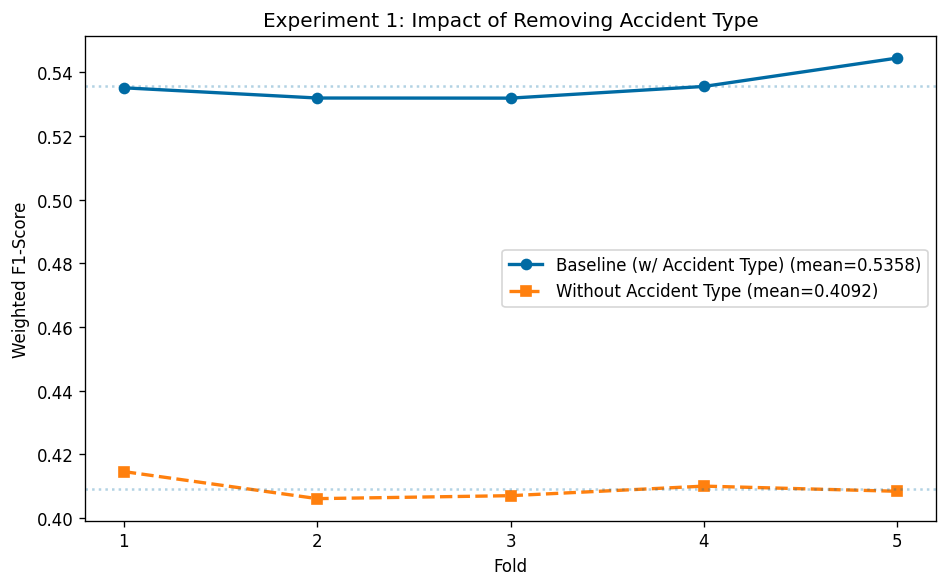

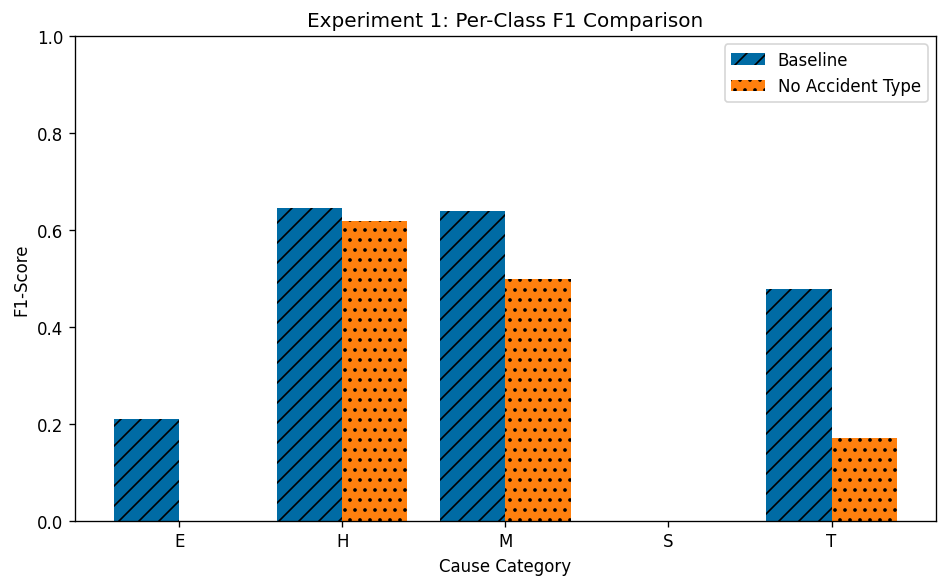

In [49]:
# Visual comparison
plot_cv_comparison(
    experiments=[
        ('Baseline (w/ Accident Type)', baseline_results['cv_scores']),
        ('Without Accident Type', results_exp1['scores'])
    ],
    title='Experiment 1: Impact of Removing Accident Type'
)

# Per-class comparison
baseline_per_class = pd.DataFrame(baseline_results['per_class_metrics'])
plot_per_class_comparison(
    [baseline_per_class, results_exp1['per_class_metrics']],
    ['Baseline', 'No Accident Type'],
    title='Experiment 1: Per-Class F1 Comparison'
)

### Experiment 1 Findings

Removing Accident Type dropped weighted F1 from 0.536 to 0.409 — a fall of 0.127. Accident Type was carrying the majority of the model's predictive load.

This is the right direction. A model relying on Accident Type answers "which crash types map to which causes?" — not "which environmental and operational conditions predict accident causes?" The 0.409 score represents honest performance on features that could actually inform prevention.

**Decision:** Drop Accident Type. The 5-feature set (Weather Condition, Track Type, Visibility, Region, RUCC_2023) is the working baseline going forward.

## Experiment 2: Track Type vs Signalization

Phase 2 found Track Type and Signalization have r = −0.52 (significant after Bonferroni correction) — Yard tracks are typically unsignalized while mainline tracks are signalized, so the features contain overlapping information. Only one should enter the model. This experiment determines which performs better.

In [50]:
# Experiment 2a: Feature set with Track Type (current baseline feature)
# Using Experiment 1 winner as starting point
# TODO: Update these lists based on Experiment 1 decision
cat_features_exp2a = ['Weather Condition', 'Track Type', 'Visibility', 'Region']
num_features_exp2a = ['RUCC_2023']

X_exp2a = df_train[cat_features_exp2a + num_features_exp2a].copy()
pipeline_exp2a = build_lr_pipeline(cat_features_exp2a, num_features_exp2a)

print("Experiment 2a: With Track Type")
print("-" * 45)
results_exp2a = run_cv_experiment(pipeline_exp2a, X_exp2a, y_train)

for fold, score in enumerate(results_exp2a['scores'], 1):
    print(f"  Fold {fold}: Weighted F1 = {score:.4f}")
print(f"\nCV: {results_exp2a['mean']:.4f} +/- {results_exp2a['std']:.4f}")

Experiment 2a: With Track Type
---------------------------------------------
  Fold 1: Weighted F1 = 0.4145
  Fold 2: Weighted F1 = 0.4060
  Fold 3: Weighted F1 = 0.4069
  Fold 4: Weighted F1 = 0.4100
  Fold 5: Weighted F1 = 0.4083

CV: 0.4092 +/- 0.0030


In [51]:
# Experiment 2b: Replace Track Type with Signalization
cat_features_exp2b = ['Weather Condition', 'Signalization', 'Visibility', 'Region']
num_features_exp2b = ['RUCC_2023']

X_exp2b = df_train[cat_features_exp2b + num_features_exp2b].copy()
pipeline_exp2b = build_lr_pipeline(cat_features_exp2b, num_features_exp2b)

print("Experiment 2b: With Signalization")
print("-" * 45)
results_exp2b = run_cv_experiment(pipeline_exp2b, X_exp2b, y_train)

for fold, score in enumerate(results_exp2b['scores'], 1):
    print(f"  Fold {fold}: Weighted F1 = {score:.4f}")
print(f"\nCV: {results_exp2b['mean']:.4f} +/- {results_exp2b['std']:.4f}")

Experiment 2b: With Signalization
---------------------------------------------
  Fold 1: Weighted F1 = 0.3857
  Fold 2: Weighted F1 = 0.3736
  Fold 3: Weighted F1 = 0.3757
  Fold 4: Weighted F1 = 0.3791
  Fold 5: Weighted F1 = 0.3770

CV: 0.3782 +/- 0.0042


In [52]:
# Save both runs
save_experiment(
    results_exp2a,
    features={'categorical': cat_features_exp2a, 'numeric': num_features_exp2a},
    experiment_name='LR with Track Type',
    filepath='results/lr/lr_exp_track_type.json'
)

save_experiment(
    results_exp2b,
    features={'categorical': cat_features_exp2b, 'numeric': num_features_exp2b},
    experiment_name='LR with Signalization',
    filepath='results/lr/lr_exp_signalization.json'
)

# Compare
compare_experiments(
    names=['With Track Type', 'With Signalization'],
    filepaths=['results/lr/lr_exp_track_type.json', 'results/lr/lr_exp_signalization.json']
)

Saved: results/lr/lr_exp_track_type.json
Saved: results/lr/lr_exp_signalization.json
Experiment                             CV Mean     CV Std Features
-----------------------------------------------------------------
With Track Type                         0.4092     0.0030        5
With Signalization                      0.3782     0.0042        5


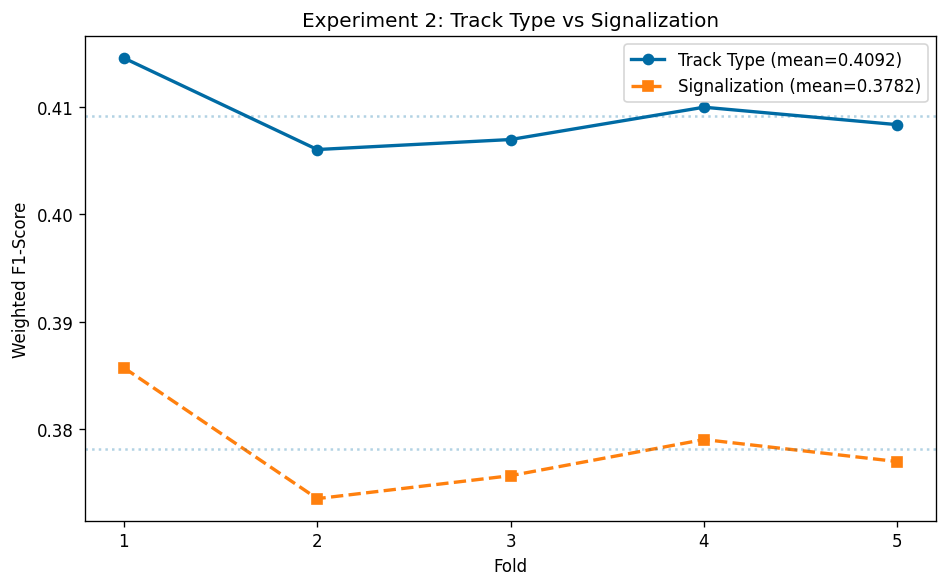

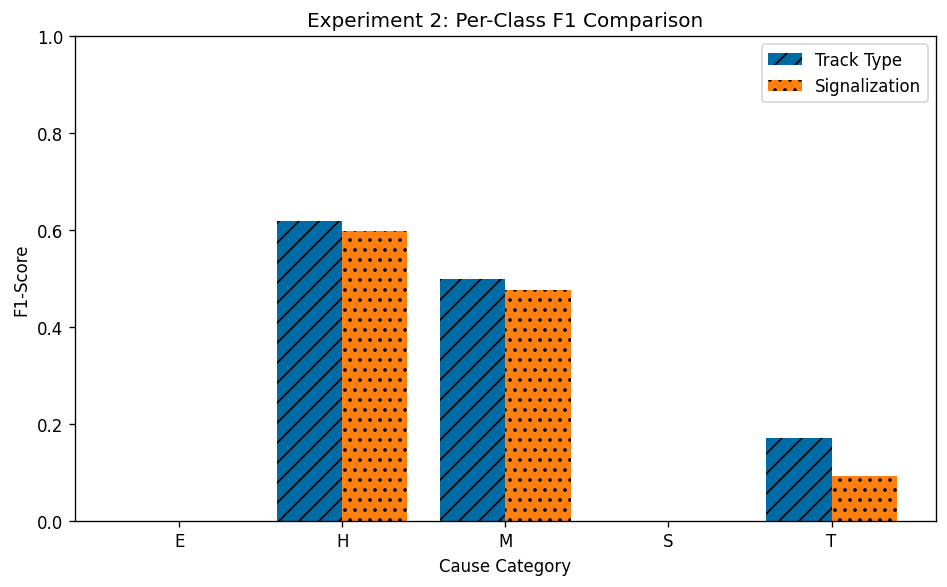

In [53]:
plot_cv_comparison(
    experiments=[
        ('Track Type', results_exp2a['scores']),
        ('Signalization', results_exp2b['scores'])
    ],
    title='Experiment 2: Track Type vs Signalization'
)

plot_per_class_comparison(
    [results_exp2a['per_class_metrics'], results_exp2b['per_class_metrics']],
    ['Track Type', 'Signalization'],
    title='Experiment 2: Per-Class F1 Comparison'
)

### Experiment 2 Findings

Track Type outperformed Signalization by 0.031 F1 (0.409 vs 0.378). Track Type's 4 categories (Main, Yard, Industry, Siding) carry more granular operational signal than Signalization's binary split — and it was already in the baseline.

**Decision:** Keep Track Type, drop Signalization.

## Experiment 3: RUCC_2023 vs RUCC_Metro_Adjacency

These two features are r = 0.87 correlated (one is derived from the other). RUCC_Metro_Adjacency collapses the 9-code RUCC scale into 3 bins: Metro, Nonmetro Adjacent, Nonmetro Nonadjacent. For LR with OneHotEncoding, that's 3 binary columns instead of 9 — fewer parameters, simpler model, potentially cleaner generalization. This experiment tests whether the compression costs any predictive performance.

In [54]:
# Experiment 3a: Raw RUCC_2023 as numeric (current baseline approach)
# TODO: Update categorical list based on Exp 1 and 2 decisions
cat_features_exp3a = ['Weather Condition', 'Track Type', 'Visibility', 'Region']
num_features_exp3a = ['RUCC_2023']

X_exp3a = df_train[cat_features_exp3a + num_features_exp3a].copy()
pipeline_exp3a = build_lr_pipeline(cat_features_exp3a, num_features_exp3a)

print("Experiment 3a: RUCC_2023 (raw, numeric)")
print("-" * 45)
results_exp3a = run_cv_experiment(pipeline_exp3a, X_exp3a, y_train)

for fold, score in enumerate(results_exp3a['scores'], 1):
    print(f"  Fold {fold}: Weighted F1 = {score:.4f}")
print(f"\nCV: {results_exp3a['mean']:.4f} +/- {results_exp3a['std']:.4f}")

Experiment 3a: RUCC_2023 (raw, numeric)
---------------------------------------------
  Fold 1: Weighted F1 = 0.4145
  Fold 2: Weighted F1 = 0.4060
  Fold 3: Weighted F1 = 0.4069
  Fold 4: Weighted F1 = 0.4100
  Fold 5: Weighted F1 = 0.4083

CV: 0.4092 +/- 0.0030


In [55]:
# Experiment 3b: RUCC_Metro_Adjacency as categorical (3 bins)
# TODO: Update based on Exp 1 and 2 decisions
cat_features_exp3b = ['Weather Condition', 'Track Type', 'Visibility', 'Region', 
                       'RUCC_Metro_Adjacency']
num_features_exp3b = []

X_exp3b = df_train[cat_features_exp3b + num_features_exp3b].copy()
pipeline_exp3b = build_lr_pipeline(cat_features_exp3b, num_features_exp3b)

print("Experiment 3b: RUCC_Metro_Adjacency (binned, categorical)")
print("-" * 45)
results_exp3b = run_cv_experiment(pipeline_exp3b, X_exp3b, y_train)

for fold, score in enumerate(results_exp3b['scores'], 1):
    print(f"  Fold {fold}: Weighted F1 = {score:.4f}")
print(f"\nCV: {results_exp3b['mean']:.4f} +/- {results_exp3b['std']:.4f}")

Experiment 3b: RUCC_Metro_Adjacency (binned, categorical)
---------------------------------------------
  Fold 1: Weighted F1 = 0.4161
  Fold 2: Weighted F1 = 0.4070
  Fold 3: Weighted F1 = 0.4083
  Fold 4: Weighted F1 = 0.4114
  Fold 5: Weighted F1 = 0.4024

CV: 0.4091 +/- 0.0046


In [56]:
# Save both runs
save_experiment(
    results_exp3a,
    features={'categorical': cat_features_exp3a, 'numeric': num_features_exp3a},
    experiment_name='LR with RUCC_2023 (raw)',
    filepath='results/lr/lr_exp_rucc_raw.json'
)

save_experiment(
    results_exp3b,
    features={'categorical': cat_features_exp3b, 'numeric': num_features_exp3b},
    experiment_name='LR with RUCC_Metro_Adjacency (binned)',
    filepath='results/lr/lr_exp_rucc_binned.json'
)

# Compare
compare_experiments(
    names=['RUCC_2023 (raw)', 'RUCC_Metro_Adjacency (binned)'],
    filepaths=['results/lr/lr_exp_rucc_raw.json', 'results/lr/lr_exp_rucc_binned.json']
)

Saved: results/lr/lr_exp_rucc_raw.json
Saved: results/lr/lr_exp_rucc_binned.json
Experiment                             CV Mean     CV Std Features
-----------------------------------------------------------------
RUCC_2023 (raw)                         0.4092     0.0030        5
RUCC_Metro_Adjacency (binned)           0.4091     0.0046        5


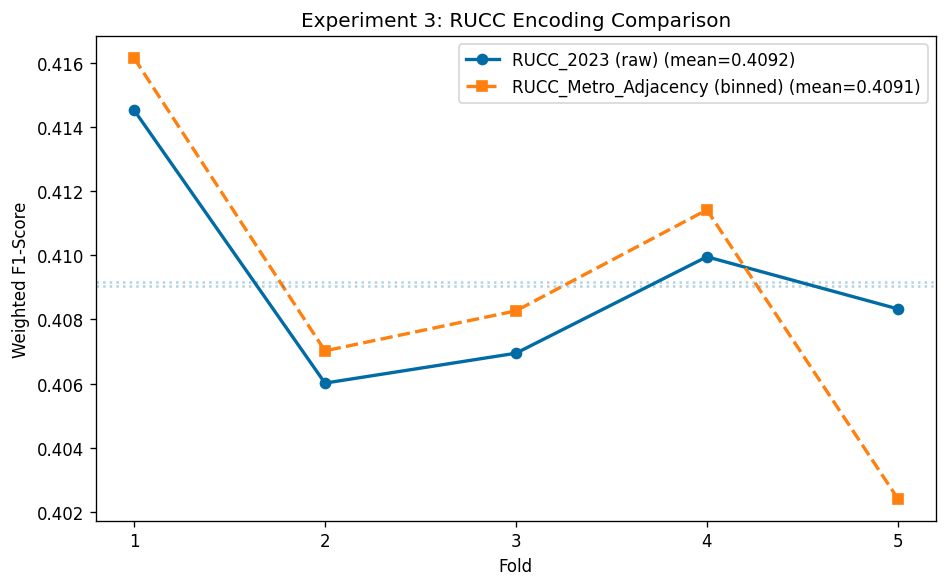

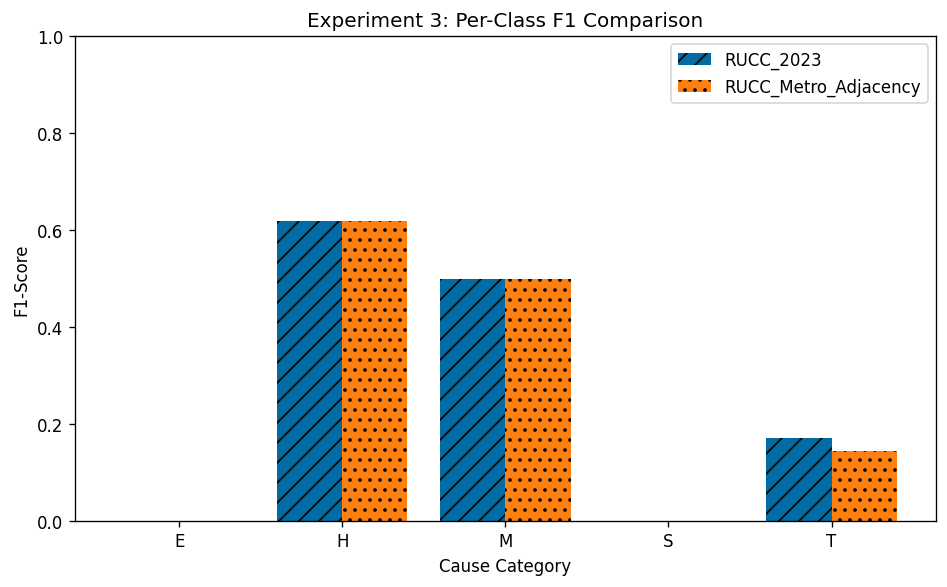

In [57]:
plot_cv_comparison(
    experiments=[
        ('RUCC_2023 (raw)', results_exp3a['scores']),
        ('RUCC_Metro_Adjacency (binned)', results_exp3b['scores'])
    ],
    title='Experiment 3: RUCC Encoding Comparison'
)

plot_per_class_comparison(
    [results_exp3a['per_class_metrics'], results_exp3b['per_class_metrics']],
    ['RUCC_2023', 'RUCC_Metro_Adjacency'],
    title='Experiment 3: Per-Class F1 Comparison'
)

### Experiment 3 Findings

RUCC_2023 and RUCC_Metro_Adjacency performed identically: 0.4092 vs 0.4091. The tie goes to interpretability — three bins (Metro, Nonmetro Adjacent, Nonmetro Nonadjacent) map directly to the Phase 1 finding that rural counties have different accident profiles than metro counties. Nine numeric RUCC codes do not.

**Decision:** Use RUCC_Metro_Adjacency. Locked feature set: Weather Condition, Track Type, Visibility, Region, RUCC_Metro_Adjacency (all categorical, no numeric features).

---

## Feature Set: Locked

| Experiment | Decision | Rationale |
|---|---|---|
| Accident Type | Drop | Label leakage — maps near-deterministically to Cause_Category |
| Track Type vs Signalization | Track Type | 0.031 F1 advantage, more granular (4 vs 2 categories) |
| RUCC encoding | RUCC_Metro_Adjacency | Identical performance, better interpretability |

**Final feature set:** Weather Condition, Track Type, Visibility, Region, RUCC_Metro_Adjacency

All subsequent tuning experiments use this locked feature set.

# Section 2: Hyperparameter Tuning

Feature set locked. Now testing whether any hyperparameter configuration improves on sklearn's defaults (L-BFGS, L2, C=1.0).

## Experiment 4: GridSearchCV — L-BFGS / L2

Grid search over 6 C values (0.01–10.0) and 2 class weighting options (None, balanced). 12 total combinations, each evaluated with 5-fold stratified CV.

In [58]:
# TODO: Update these to the locked feature set from experiments 1-3
cat_features_final = ['Weather Condition', 'Track Type', 'Visibility', 'Region', 'RUCC_Metro_Adjacency']
num_features_final = []

X_final = df_train[cat_features_final + num_features_final].copy()

# Build base pipeline for GridSearch
pipeline_grid = build_lr_pipeline(cat_features_final, num_features_final)

# Define parameter grid
# C controls regularization strength: smaller C = stronger regularization
# class_weight: None uses equal weights, 'balanced' adjusts inversely to class frequency
param_grid = {
    'classifier__C': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
    'classifier__class_weight': [None, 'balanced']
}

# GridSearchCV with weighted F1 as scoring metric
grid_search = GridSearchCV(
    pipeline_grid,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    scoring='f1_weighted',
    n_jobs=-1,
    refit=True,
    verbose=1
)

print("Running GridSearchCV on baseline LR...")
print(f"Parameter combinations: {len(param_grid['classifier__C']) * len(param_grid['classifier__class_weight'])}")
grid_search.fit(X_final, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")

Running GridSearchCV on baseline LR...
Parameter combinations: 12
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters: {'classifier__C': 1.0, 'classifier__class_weight': None}
Best CV score: 0.4091


In [59]:
# Display all GridSearch results sorted by score
grid_results = pd.DataFrame(grid_search.cv_results_)
grid_display = grid_results[['param_classifier__C', 'param_classifier__class_weight', 
                              'mean_test_score', 'std_test_score', 'rank_test_score']]
grid_display = grid_display.sort_values('rank_test_score')
grid_display.columns = ['C', 'class_weight', 'Mean F1', 'Std F1', 'Rank']

# Replace NaN class_weight with 'None' for display
grid_display['class_weight'] = grid_display['class_weight'].fillna('None')

print("GridSearchCV Results (sorted by rank):")
print(grid_display.to_string(index=False))

GridSearchCV Results (sorted by rank):
    C class_weight  Mean F1   Std F1  Rank
 1.00         None 0.409053 0.004574     1
 5.00         None 0.409053 0.004574     1
10.00         None 0.409053 0.004574     1
 0.01         None 0.408836 0.004698     4
 0.10         None 0.408823 0.004697     5
 0.50         None 0.408823 0.004697     5
 0.01     balanced 0.298561 0.006832     7
 0.10     balanced 0.297506 0.007239     8
 0.50     balanced 0.297506 0.007239     8
 1.00     balanced 0.297506 0.007239     8
 5.00     balanced 0.297506 0.007239     8
10.00     balanced 0.297506 0.007239     8


In [60]:
# Run CV with best params to get detailed metrics
pipeline_best_grid = build_lr_pipeline(
    cat_features_final, num_features_final,
    C=grid_search.best_params_['classifier__C'],
    class_weight=grid_search.best_params_['classifier__class_weight']
)

results_exp4 = run_cv_experiment(pipeline_best_grid, X_final, y_train)

print(f"Best GridSearch LR CV: {results_exp4['mean']:.4f} +/- {results_exp4['std']:.4f}")
print(f"\nPer-class metrics:")
print(results_exp4['per_class_metrics'].to_string(index=False))

# Save
save_experiment(
    results_exp4,
    features={'categorical': cat_features_final, 'numeric': num_features_final},
    experiment_name='LR GridSearchCV (L-BFGS, L2)',
    filepath='results/lr/lr_tuned_gridsearch.json',
    best_params=grid_search.best_params_,
    param_grid_searched={k: [str(v) for v in vals] for k, vals in param_grid.items()}
)

Best GridSearch LR CV: 0.4091 +/- 0.0046

Per-class metrics:
Cause  Precision  Recall    F1
    E      0.000   0.000 0.000
    H      0.504   0.802 0.619
    M      0.441   0.576 0.499
    S      0.000   0.000 0.000
    T      0.462   0.085 0.144
Saved: results/lr/lr_tuned_gridsearch.json


### Experiment 4 Findings

GridSearchCV tested 12 combinations across 6 C values (0.01 to 10.0) and 2 class_weight options (None, balanced). The top 6 configurations span a range of just 0.0002 F1, all with class_weight=None. C=1.0 (the sklearn default) tied for first.

class_weight='balanced' consistently degraded performance to 0.297-0.299, matching the baseline notebook finding. Upweighting minority classes causes the model to over-predict rare categories at the expense of majority class accuracy.

Per-class metrics are unchanged from Experiment 1: zero predictions for Signal and Environmental, strong Human Factor recall (0.80), weak Track recall (0.085). No C value altered this pattern.

**Decision:** Keep defaults (C=1.0, no class weighting). The grid search confirmed that hyperparameter tuning cannot push past the 0.409 ceiling.

## Experiment 5a: SAGA Solver with L1 Penalty

L1 (Lasso) regularization drives some coefficients to exactly zero — unlike L2, which shrinks them toward zero but never eliminates them. This makes L1 useful as a diagnostic: if the model zeros out a feature across all 5 cause classes, that feature isn't contributing and could be dropped.

SAGA solver is required for L1 in sklearn. Default C=1.0 to match Experiment 4's baseline.

In [61]:
# Experiment 5a: SAGA solver with L1 penalty, default C=1.0
pipeline_saga = build_lr_pipeline(
    cat_features_final, num_features_final,
    solver='saga',
    penalty='l1',
    max_iter=5000  # SAGA may need more iterations to converge
)

print("Experiment 5: SAGA L1 (default C=1.0)")
print("-" * 45)
results_exp5 = run_cv_experiment(pipeline_saga, X_final, y_train)

for fold, score in enumerate(results_exp5['scores'], 1):
    print(f"  Fold {fold}: Weighted F1 = {score:.4f}")
print(f"\nCV: {results_exp5['mean']:.4f} +/- {results_exp5['std']:.4f}")

Experiment 5: SAGA L1 (default C=1.0)
---------------------------------------------
  Fold 1: Weighted F1 = 0.4164
  Fold 2: Weighted F1 = 0.4059
  Fold 3: Weighted F1 = 0.4083
  Fold 4: Weighted F1 = 0.4114
  Fold 5: Weighted F1 = 0.4024

CV: 0.4089 +/- 0.0048


In [62]:
# Analyze which features L1 zeroed out
# Refit on full training data to inspect coefficients
pipeline_saga.fit(X_final, y_train)

# Get feature names after OneHotEncoding
ohe = pipeline_saga.named_steps['preprocessor'].transformers_[0][1]
cat_feature_names = ohe.get_feature_names_out(cat_features_final).tolist()
all_feature_names = cat_feature_names + num_features_final

# Get coefficients (one row per class)
coefs = pipeline_saga.named_steps['classifier'].coef_
classes = pipeline_saga.named_steps['classifier'].classes_

# Count zeros per class
print("L1 Sparsity Analysis:")
print("-" * 50)
for i, cls in enumerate(classes):
    n_zero = np.sum(coefs[i] == 0)
    n_total = len(coefs[i])
    print(f"  Class {cls} ({CAUSE_LABELS.get(cls, cls)}): {n_zero}/{n_total} coefficients zeroed ({n_zero/n_total:.0%})")

# Show which features were zeroed across ALL classes
all_zero_mask = np.all(coefs == 0, axis=0)
zeroed_features = [name for name, is_zero in zip(all_feature_names, all_zero_mask) if is_zero]
kept_features = [name for name, is_zero in zip(all_feature_names, all_zero_mask) if not is_zero]

print(f"\nFeatures zeroed across ALL classes: {len(zeroed_features)}")
for f in zeroed_features:
    print(f"  - {f}")

print(f"\nFeatures retained by at least one class: {len(kept_features)}")
for f in kept_features:
    print(f"  + {f}")

L1 Sparsity Analysis:
--------------------------------------------------
  Class E (Environmental): 8/21 coefficients zeroed (38%)
  Class H (Human Factor): 11/21 coefficients zeroed (52%)
  Class M (Mechanical): 7/21 coefficients zeroed (33%)
  Class S (Signal): 8/21 coefficients zeroed (38%)
  Class T (Track): 6/21 coefficients zeroed (29%)

Features zeroed across ALL classes: 0

Features retained by at least one class: 21
  + Weather Condition_Clear
  + Weather Condition_Cloudy
  + Weather Condition_Fog
  + Weather Condition_Rain
  + Weather Condition_Sleet
  + Weather Condition_Snow
  + Track Type_Industry
  + Track Type_Main
  + Track Type_Siding
  + Track Type_Yard
  + Visibility_Dark
  + Visibility_Dawn
  + Visibility_Day
  + Visibility_Dusk
  + Region_Midwest
  + Region_Northeast
  + Region_South
  + Region_West
  + RUCC_Metro_Adjacency_Metro
  + RUCC_Metro_Adjacency_Nonmetro_Adjacent
  + RUCC_Metro_Adjacency_Nonmetro_Nonadjacent


In [63]:
save_experiment(
    results_exp5,
    features={'categorical': cat_features_final, 'numeric': num_features_final},
    experiment_name='LR SAGA L1 (default C=1.0)',
    filepath='results/lr/lr_tuned_saga_l1.json',
    lr_params={'solver': 'saga', 'penalty': 'l1', 'C': 1.0},
    sparsity={
        'zeroed_all_classes': zeroed_features,
        'kept_features': kept_features
    }
)

Saved: results/lr/lr_tuned_saga_l1.json


### Experiment 5a Findings: L1 Sparsity Analysis

SAGA L1 matched L-BFGS L2 performance: 0.4089 vs 0.4091. The solver and penalty change did not improve classification.

**The sparsity result:** No feature was zeroed across all 5 cause classes — every feature in the set contributes to predicting at least one cause. The feature set has no dead weight.

Per-class sparsity ranged from 29% (Track) to 52% (Human Factor), and the pattern is meaningful:
- **H (52% zeroed):** The majority class needs the fewest active features — the model defaults to H when no strong signal exists
- **T (29% zeroed):** Uses the broadest feature set, consistent with Track failures depending on a wider combination of conditions
- **E, S, M (33–38% zeroed):** Moderate sparsity, each relying on a different feature subset

This validates the Phase 2 feature selection: different causes depend on different features, and no feature is universally redundant.

**Decision:** SAGA L1 does not improve on L-BFGS L2. Proceed with GridSearchCV on SAGA L1 to test whether tuning C changes the outcome.

### Experiment 5b: L1 Sparsity with Accident Type Included

Running the same L1 sparsity analysis with Accident Type in the feature set. If it's truly dominant, its coefficients should dwarf everything else — and other features should shrink toward irrelevance.

In [64]:
# Experiment 5b: SAGA L1 WITH Accident Type to demonstrate dominance
cat_features_exp5b = ['Weather Condition', 'Track Type', 'Visibility', 'Region', 
                       'RUCC_Metro_Adjacency', 'Accident Type']
num_features_exp5b = []

X_exp5b = df_train[cat_features_exp5b + num_features_exp5b].copy()

pipeline_saga_5b = build_lr_pipeline(
    cat_features_exp5b, num_features_exp5b,
    solver='saga', penalty='l1', max_iter=5000
)

# Fit on full training set for coefficient inspection
pipeline_saga_5b.fit(X_exp5b, y_train)

# Get feature names and coefficients
ohe_5b = pipeline_saga_5b.named_steps['preprocessor'].transformers_[0][1]
all_feature_names_5b = ohe_5b.get_feature_names_out(cat_features_exp5b).tolist()

coefs_5b = pipeline_saga_5b.named_steps['classifier'].coef_
classes_5b = pipeline_saga_5b.named_steps['classifier'].classes_

# Compare sparsity: with vs without Accident Type
print("L1 Sparsity Comparison: With vs Without Accident Type")
print("=" * 65)
print(f"{'Class':<25} {'Without AT':>15} {'With AT':>15}")
print("-" * 65)

# Without AT sparsity (from Experiment 5)
without_at_sparsity = {
    'E': '8/21 (38%)', 'H': '11/21 (52%)', 
    'M': '7/21 (33%)', 'S': '8/21 (38%)', 'T': '6/21 (29%)'
}

for i, cls in enumerate(classes_5b):
    n_zero = np.sum(coefs_5b[i] == 0)
    n_total = len(coefs_5b[i])
    with_at = f"{n_zero}/{n_total} ({n_zero/n_total:.0%})"
    without_at = without_at_sparsity.get(cls, 'N/A')
    label = f"{cls} ({CAUSE_LABELS.get(cls, cls)})"
    print(f"{label:<25} {without_at:>15} {with_at:>15}")

# Show top 10 features by absolute coefficient magnitude (averaged across classes)
mean_abs_coefs = np.mean(np.abs(coefs_5b), axis=0)
top_idx = np.argsort(mean_abs_coefs)[::-1][:10]

print(f"\nTop 10 features by mean absolute coefficient:")
print("-" * 50)
for idx in top_idx:
    print(f"  {all_feature_names_5b[idx]:<45} {mean_abs_coefs[idx]:.4f}")

# Count how many Accident Type features are in top 10
at_in_top10 = sum(1 for idx in top_idx if 'Accident Type' in all_feature_names_5b[idx])
print(f"\nAccident Type features in top 10: {at_in_top10}/10")

L1 Sparsity Comparison: With vs Without Accident Type
Class                          Without AT         With AT
-----------------------------------------------------------------
E (Environmental)              8/21 (38%)     12/34 (35%)
H (Human Factor)              11/21 (52%)     11/34 (32%)
M (Mechanical)                 7/21 (33%)     12/34 (35%)
S (Signal)                     8/21 (38%)     11/34 (32%)
T (Track)                      6/21 (29%)      9/34 (26%)

Top 10 features by mean absolute coefficient:
--------------------------------------------------
  Accident Type_Hwy-rail crossing               0.6038
  Accident Type_Derailment                      0.4137
  Accident Type_Fire/violent rupture            0.2511
  Track Type_Main                               0.2076
  Accident Type_Rear end collision              0.1438
  Accident Type_Obstruction                     0.1414
  Track Type_Yard                               0.1380
  Accident Type_Other impacts                   0

### Experiment 5b Findings: Accident Type Coefficient Dominance

7 of the 10 largest coefficients belong to Accident Type. Hwy-rail crossing (0.60) is nearly 3× the magnitude of the strongest non-Accident-Type feature (Track Type_Main at 0.21). When given access to Accident Type, the model uses it overwhelmingly and treats environmental/operational features as secondary.

Sparsity counts look similar with and without Accident Type (32–38% with vs 29–52% without), but that's misleading — the surviving non-Accident-Type coefficients are much smaller in magnitude. Accident Type doesn't just compete; it crowds out.

This, combined with the ARM finding (zero rules without Accident Type), provides two independent lines of evidence that Accident Type acts as a proxy for Cause_Category — mapping near-deterministically to outcomes rather than encoding the conditions that cause them.

**Decision:** Accident Type removal validated. The 5-feature set is the right baseline.

## Experiment 6: GridSearchCV — SAGA / L1

Experiment 5a ran SAGA L1 at default C=1.0. For L1, C controls both regularization strength and sparsity simultaneously: lower C pushes more coefficients to zero, higher C allows more features to participate. Searching across 7 C values (0.01–10.0) and both class weighting options (14 total combinations) to test whether any configuration improves on 0.409.

In [65]:
# GridSearchCV for SAGA L1
pipeline_saga_grid = build_lr_pipeline(
    cat_features_final, num_features_final,
    solver='saga',
    penalty='l1',
    max_iter=5000
)

param_grid_saga = {
    'classifier__C': [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
    'classifier__class_weight': [None, 'balanced']
}

grid_search_saga = GridSearchCV(
    pipeline_saga_grid,
    param_grid_saga,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    scoring='f1_weighted',
    n_jobs=-1,
    refit=True,
    verbose=1
)

print("Running GridSearchCV on SAGA L1...")
print(f"Parameter combinations: {len(param_grid_saga['classifier__C']) * len(param_grid_saga['classifier__class_weight'])}")
grid_search_saga.fit(X_final, y_train)

print(f"\nBest parameters: {grid_search_saga.best_params_}")
print(f"Best CV score: {grid_search_saga.best_score_:.4f}")

Running GridSearchCV on SAGA L1...
Parameter combinations: 14
Fitting 5 folds for each of 14 candidates, totalling 70 fits

Best parameters: {'classifier__C': 5.0, 'classifier__class_weight': None}
Best CV score: 0.4091


In [66]:
# Display all results
grid_results_saga = pd.DataFrame(grid_search_saga.cv_results_)
grid_display_saga = grid_results_saga[['param_classifier__C', 'param_classifier__class_weight', 
                                        'mean_test_score', 'std_test_score', 'rank_test_score']]
grid_display_saga = grid_display_saga.sort_values('rank_test_score')
grid_display_saga.columns = ['C', 'class_weight', 'Mean F1', 'Std F1', 'Rank']

# Replace NaN class_weight with 'None' for display
grid_display_saga['class_weight'] = grid_display_saga['class_weight'].fillna('None')

print("GridSearchCV Results - SAGA L1 (sorted by rank):")
print(grid_display_saga.to_string(index=False))

GridSearchCV Results - SAGA L1 (sorted by rank):
    C class_weight  Mean F1   Std F1  Rank
 5.00         None 0.409113 0.004668     1
10.00         None 0.409053 0.004574     2
 0.50         None 0.409010 0.004718     3
 1.00         None 0.408884 0.004792     4
 0.05         None 0.408759 0.004744     5
 0.10         None 0.408736 0.004548     6
 0.01         None 0.407098 0.003491     7
 0.10     balanced 0.297629 0.006419     8
 1.00     balanced 0.297580 0.007260     9
 5.00     balanced 0.297506 0.007239    10
10.00     balanced 0.297506 0.007239    10
 0.50     balanced 0.297466 0.007132    12
 0.05     balanced 0.295741 0.007459    13
 0.01     balanced 0.282396 0.008280    14


In [68]:
# Run CV with best SAGA params for detailed metrics
pipeline_best_saga = build_lr_pipeline(
    cat_features_final, num_features_final,
    solver='saga',
    penalty='l1',
    max_iter=5000,
    C=grid_search_saga.best_params_['classifier__C'],
    class_weight=grid_search_saga.best_params_['classifier__class_weight']
)

results_exp6 = run_cv_experiment(pipeline_best_saga, X_final, y_train)

print(f"Best SAGA L1 CV: {results_exp6['mean']:.4f} +/- {results_exp6['std']:.4f}")
print(f"\nPer-class metrics:")
print(results_exp6['per_class_metrics'].to_string(index=False))

# Save
save_experiment(
    results_exp6,
    features={'categorical': cat_features_final, 'numeric': num_features_final},
    experiment_name='LR GridSearchCV (SAGA, L1)',
    filepath='results/lr/lr_tuned_saga_l1_gridsearch.json',
    best_params=grid_search_saga.best_params_,
    param_grid_searched={k: [str(v) for v in vals] for k, vals in param_grid_saga.items()}
)

Best SAGA L1 CV: 0.4091 +/- 0.0047

Per-class metrics:
Cause  Precision  Recall    F1
    E      0.000   0.000 0.000
    H      0.504   0.802 0.619
    M      0.441   0.576 0.499
    S      0.000   0.000 0.000
    T      0.462   0.085 0.144
Saved: results/lr/lr_tuned_saga_l1_gridsearch.json


### Experiment 6 Findings: Optimizing SAGA L1

Best configuration: C=5.0, no class weighting, F1 = 0.4091 — the same score as everything else. The top 6 results span just 0.002 F1 (0.407–0.409). Regularization strength has almost no effect on this feature set.

`class_weight='balanced'` collapsed to 0.28–0.30 across all 7 C values, consistent with every prior experiment. Class weighting forces predictions the model can't support.

Per-class metrics: unchanged across every LR configuration tested. Zero precision and recall for Signal and Environmental, H recall 0.80, M recall 0.58, T recall 0.085. No hyperparameter combination changed this pattern.

**The ceiling is the feature set, not the hyperparameters.** Eight experiments across two solvers, two penalties, seven C values, and two class weighting options all converged on 0.409. Improving LR further requires more informative features or a fundamentally different approach to class imbalance.

---

# Final Summary

## All Experiments Compared

In [69]:
# Load and compare all saved experiments
import os

lr_results_dir = 'results/lr/'
all_files = sorted([f for f in os.listdir(lr_results_dir) if f.endswith('.json')])

print("=" * 75)
print(f"{'Experiment':<45} {'CV Mean':>10} {'CV Std':>10} {'Features':>8}")
print("-" * 75)

for f in all_files:
    filepath = os.path.join(lr_results_dir, f)
    with open(filepath, 'r') as fh:
        data = json.load(fh)
    
    name = data.get('experiment', f.replace('.json', ''))
    mean = data.get('cv_mean', 0)
    std = data.get('cv_std', 0)
    
    if isinstance(data.get('features'), dict):
        n_feat = data['features']['total']
    elif isinstance(data.get('features'), list):
        n_feat = len(data['features'])
    else:
        n_feat = '?'
    
    print(f"{name:<45} {mean:>10.4f} {std:>10.4f} {n_feat:>8}")

print("=" * 75)

Experiment                                       CV Mean     CV Std Features
---------------------------------------------------------------------------
LR Baseline (with Accident Type)                  0.5358     0.0046        6
LR Baseline without Accident Type                 0.4092     0.0030        5
LR with RUCC_Metro_Adjacency (binned)             0.4091     0.0046        5
LR with RUCC_2023 (raw)                           0.4092     0.0030        5
LR with Signalization                             0.3782     0.0042        5
LR with Track Type                                0.4092     0.0030        5
Logistic Regression Final Test Evaluation         0.4091     0.0046        ?
LR GridSearchCV (L-BFGS, L2)                      0.4091     0.0046        5
LR SAGA L1 (default C=1.0)                        0.4089     0.0048        5
LR GridSearchCV (SAGA, L1)                        0.4091     0.0047        5


In [70]:
import joblib
# Save the final tuned LR pipeline
# Best config: L-BFGS, L2, C=1.0, no class weighting, 5 features
final_features_cat = ['Weather Condition', 'Track Type', 'Visibility', 'Region', 'RUCC_Metro_Adjacency']
final_features_num = []

final_pipeline = build_lr_pipeline(final_features_cat, final_features_num)

X_final = df_train[final_features_cat + final_features_num]
final_pipeline.fit(X_final, y_train)

joblib.dump(final_pipeline, 'models/lr_tuned_pipeline.pkl')
print("Saved: models/lr_tuned_pipeline.pkl")

Saved: models/lr_tuned_pipeline.pkl


## Conclusions

This notebook systematically tested feature selection and hyperparameter tuning for Logistic Regression across 8 experiments (including Experiment 5b). Every experiment saved results to JSON for reproducibility and comparison.

**Best LR configuration:** L-BFGS, L2, C=1.0, no class weighting — sklearn defaults — on 5 features: Weather Condition, Track Type, Visibility, Region, RUCC_Metro_Adjacency. No tuning improved on the defaults.

**Key findings:**

1. **Removing Accident Type dropped F1 from 0.536 to 0.409 (−0.127).** Experiment 5b confirmed why: 7 of the 10 largest L1 coefficients belonged to Accident Type, with Hwy-rail crossing (0.60) nearly 3× the magnitude of the next feature. The 0.409 score represents honest performance on features with operational prevention value.

2. **Track Type outperformed Signalization by 0.031 F1 (0.409 vs 0.378).** Track Type's 4 categories capture more granular operational context than Signalization's binary split.

3. **RUCC_2023 and RUCC_Metro_Adjacency performed identically (0.4092 vs 0.4091).** RUCC_Metro_Adjacency was selected for interpretability: 3 meaningful bins vs 9 numeric codes.

4. **The 0.409 ceiling is a feature limitation, not a hyperparameter limitation.** Two solvers, two penalties, seven C values, and two class weighting options all converged on the same score. The feature set is fully exploited.

5. **L1 sparsity confirmed no dead weight in the feature set.** Every feature was retained by at least one cause class. Per-class sparsity (29–52%) shows different causes rely on different feature subsets — operationally coherent.

6. **class_weight='balanced' consistently degraded performance to 0.28–0.30** across every configuration. Upweighting minority classes forces predictions the model can't support given only 5 categorical features and severe class imbalance.

---
*Model saved:* `models/lr_tuned_pipeline.pkl` · *Results:* `results/lr/`